In [1]:
!pip install shap

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In [5]:
df = pd.read_csv("HRDataset_v14.csv")
df.head()

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,"Adinolfi, Wilson K",10026,0,0,1,1,5,4,0,62506,...,Michael Albert,22.0,LinkedIn,Exceeds,4.60,5,0,1/17/2019,0,1
1,"Ait Sidi, Karthikeyan",10084,1,1,1,5,3,3,0,104437,...,Simon Roup,4.0,Indeed,Fully Meets,4.96,3,6,2/24/2016,0,17
2,"Akinkuolie, Sarah",10196,1,1,0,5,5,3,0,64955,...,Kissy Sullivan,20.0,LinkedIn,Fully Meets,3.02,3,0,5/15/2012,0,3
3,"Alagbe,Trina",10088,1,1,0,1,5,3,0,64991,...,Elijiah Gray,16.0,Indeed,Fully Meets,4.84,5,0,1/3/2019,0,15
4,"Anderson, Carol",10069,0,2,0,5,5,3,0,50825,...,Webster Butler,39.0,Google Search,Fully Meets,5.00,4,0,2/1/2016,0,2


In [6]:
columns_to_drop = [
    "Employee_Name",
    "EmpID",
    "DateofTermination",
    "TermReason",
    "EmploymentStatus",
    "EmploymentStatusID",
    "EmpStatusID",
    "ManagerID"
]

df = df.drop(columns=columns_to_drop, errors="ignore")

In [7]:
print(df.columns.tolist())

['MarriedID', 'MaritalStatusID', 'GenderID', 'DeptID', 'PerfScoreID', 'FromDiversityJobFairID', 'Salary', 'Termd', 'PositionID', 'Position', 'State', 'Zip', 'DOB', 'Sex', 'MaritalDesc', 'CitizenDesc', 'HispanicLatino', 'RaceDesc', 'DateofHire', 'Department', 'ManagerName', 'RecruitmentSource', 'PerformanceScore', 'EngagementSurvey', 'EmpSatisfaction', 'SpecialProjectsCount', 'LastPerformanceReview_Date', 'DaysLateLast30', 'Absences']


In [8]:
df = pd.get_dummies(df, drop_first=True)

In [9]:
X = df.drop("Termd", axis=1)
y = df["Termd"]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [12]:
preds = model.predict(X_test)
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.69      0.98      0.81        41
           1       0.80      0.18      0.30        22

    accuracy                           0.70        63
   macro avg       0.74      0.58      0.55        63
weighted avg       0.73      0.70      0.63        63



In [13]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

In [14]:
if isinstance(shap_values, list):
    shap_values_pos = shap_values[1]
else:
    shap_values_pos = shap_values[:, :, 1] if len(shap_values.shape) == 3 else shap_values

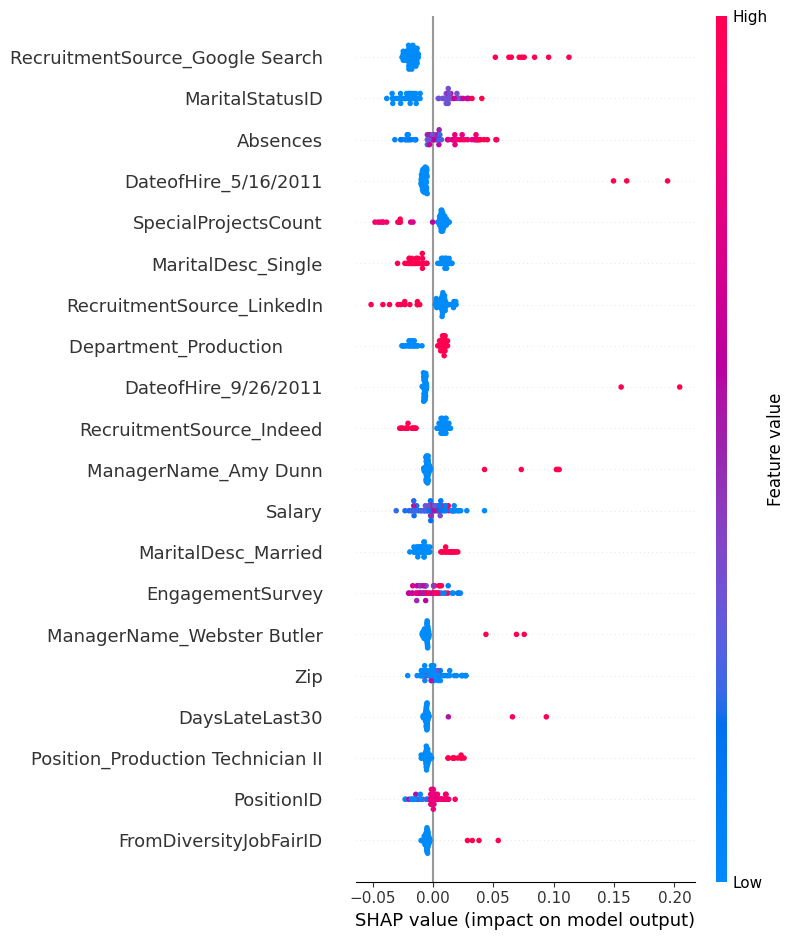

In [15]:
shap.summary_plot(shap_values_pos, X_test)

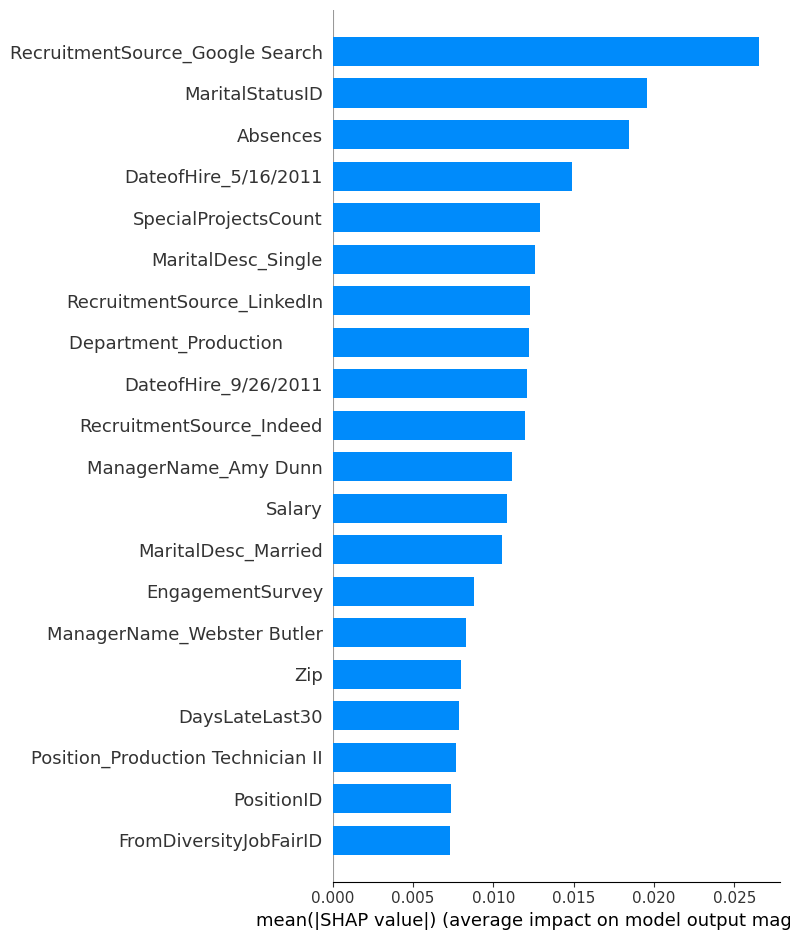

In [16]:
shap.summary_plot(shap_values_pos, X_test, plot_type="bar")

In [17]:
employee_idx = 0

In [18]:
proba = model.predict_proba(X_test.iloc[[employee_idx]])[0, 1]
print(f"Predicted probability of leaving: {proba:.2%}")

Predicted probability of leaving: 31.00%


In [19]:
feature_contrib = pd.Series(shap_values_pos[employee_idx], index=X_test.columns)

print("Top factors increasing resignation risk:")
print(feature_contrib.sort_values(ascending=False).head(3))

print("\nTop factors decreasing resignation risk:")
print(feature_contrib.sort_values().head(3))

Top factors increasing resignation risk:
Absences              0.036246
MaritalStatusID       0.028036
MaritalDesc_Single    0.009878
dtype: float64

Top factors decreasing resignation risk:
RecruitmentSource_Google Search   -0.018918
MaritalDesc_Married               -0.012625
PositionID                        -0.010180
dtype: float64


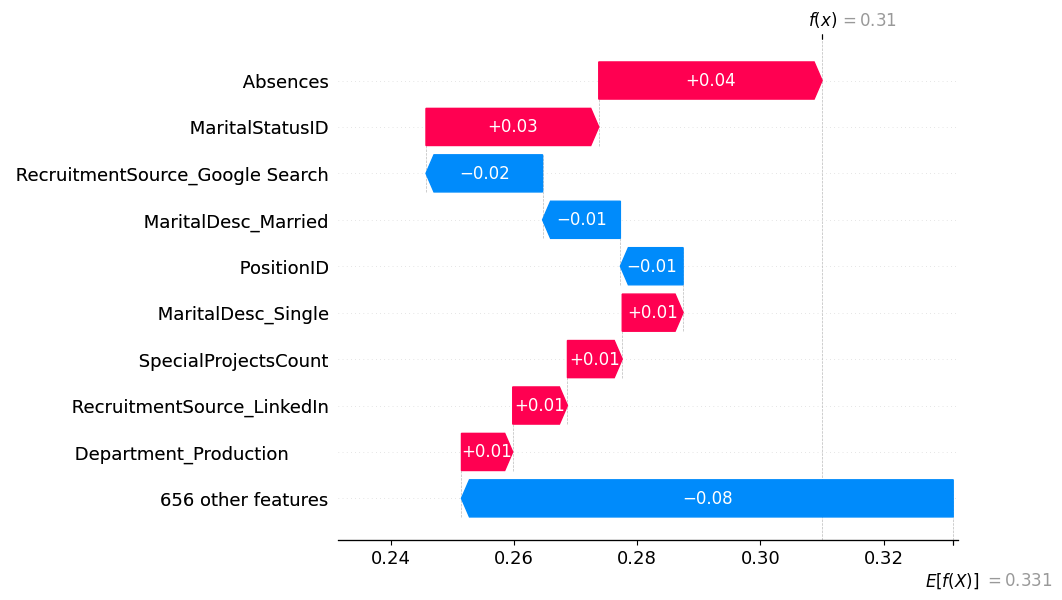

In [20]:
base_value = explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value

shap.plots._waterfall.waterfall_legacy(
    base_value,
    shap_values_pos[employee_idx],
    X_test.iloc[employee_idx]
)

**Two Employees Case Study**

In [21]:
# Predicted probabilities
probas = model.predict_proba(X_test)[:, 1]

# Highest-risk and lowest-risk employees
high_idx = np.argmax(probas)
low_idx = np.argmin(probas)

print("High-risk employee probability:", probas[high_idx])
print("Low-risk employee probability:", probas[low_idx])

High-risk employee probability: 0.635
Low-risk employee probability: 0.03


In [22]:
# Predicted probabilities
probas = model.predict_proba(X_test)[:, 1]

# Highest-risk and lowest-risk employees
high_idx = np.argmax(probas)
low_idx = np.argmin(probas)

print("High-risk employee probability:", probas[high_idx])
print("Low-risk employee probability:", probas[low_idx])

High-risk employee probability: 0.635
Low-risk employee probability: 0.03


In [26]:
def explain_with_recommendation(idx, label="Employee"):
    proba = model.predict_proba(X_test.iloc[[idx]])[0, 1]
    contrib = pd.Series(shap_values_pos[idx], index=X_test.columns)
    top_risk_features = contrib.sort_values(ascending=False).head(3).index.tolist()

    print(f"\n{label}")
    print(f"Predicted resignation risk: {proba:.2%}")
    print("Top drivers:", ", ".join(top_risk_features))

    print("\nRecommended HR actions:")
    for rec in recommend_actions(top_risk_features):
        print("-", rec)

In [27]:
def recommend_actions(feature_names):
    recommendations = []

    for f in feature_names:
        f_lower = f.lower()

        if "satisfaction" in f_lower or "engagement" in f_lower:
            recommendations.append("Schedule a manager check-in and employee listening session")

        elif "salary" in f_lower or "pay" in f_lower:
            recommendations.append("Review compensation against department benchmarks")

        elif "absence" in f_lower:
            recommendations.append("Review workload, burnout risk, and well-being support")

        elif "project" in f_lower:
            recommendations.append("Discuss growth opportunities and role development")

        elif "performance" in f_lower:
            recommendations.append("Set up coaching and performance support")

        elif "department" in f_lower or "position" in f_lower:
            recommendations.append("Review role fit and career path")

    if not recommendations:
        recommendations.append("Conduct HR follow-up interview")

    return list(dict.fromkeys(recommendations))

In [28]:
explain_with_recommendation(high_idx, "High-risk employee with recommendations")


High-risk employee with recommendations
Predicted resignation risk: 63.50%
Top drivers: DateofHire_9/26/2011, ManagerName_Webster Butler, Absences

Recommended HR actions:
- Review workload, burnout risk, and well-being support


For the Explainable AI part, we used SHAP to understand how our model makes decisions. Instead of just predicting whether an employee will leave, SHAP helps us see which factors are responsible for that prediction.

We looked at both overall trends and individual cases. For example, we can clearly see if an employee is at risk because of low satisfaction, high absences, or salary issues.

This makes the model easier to understand and helps HR know what actions to take, instead of relying on a black-box prediction.
